<center> <h1> pyABC Calibration on Heterogeneous Agent-Based Model </h1> </center>

### Import Packages

In [1]:
import random
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import statistics
import math
import numpy as np
import seaborn as sns
import pyabc
from sklearn.metrics import mean_squared_error as mse
from pyabc.visualization import plot_kde_2d
import sys
from pathlib import Path

In [ ]:
sys.path.append(str(Path("../src").resolve()))

from abm.model import Model
from abm.utils import set_seed

print("Imports working ✓")

### Figure Settings

In [46]:
plt.rc('figure', figsize=(20, 12))
plt.rcParams['font.size'] = '12'
sns.set_palette("Paired")

### Model Class

In [3]:
# class Model():

#     def __init__(self, num_of_agents, num_iterations, agent_groups): 
        
#         self.num_of_agents = num_of_agents
#         self.num_iterations = num_iterations
#         self.agent_groups = agent_groups

#         self.time = 0 #model time
        
#         #creating lists
#         self.num_infected_per_iteration = []
        
#         #create the agents
#         self.agents = []
        
#         for key in self.agent_groups.keys():
# #             print(key)
#             for i in range(round(self.agent_groups[key][2] * num_of_agents)):
#                 agent = Agent(self, key, key[0], key[1])
#                 agent.beta = self.agent_groups[key][0]
#                 agent.alpha = self.agent_groups[key][1]
# #                 print(agent)
#                 self.agents.append(agent)
        
#         self.infected_per_group = {}
        
#         for g in self.agent_groups:
#             self.infected_per_group[g] = []
        

#     def get_num_infected(self):
#         return len(([a for a in self.agents if a.state==1])) 
    
#     def run(self):
#         for t in range(self.num_iterations):
#             for agent in self.agents:
#                 if t <=1:
#                     agent.state = 0
#                 else:
#                     agent.step()
           
#             for g in self.agent_groups:
#                 group_agents = [a for a in self.agents if a.group == g]
#                 num_infected = sum([a.state for a in group_agents])
#                 self.infected_per_group[g].append(num_infected)
        
    
#             self.num_infected_per_iteration.append(self.get_num_infected())
        
        
#             self.data = pd.DataFrame(self.infected_per_group)
#             self.data.reset_index(inplace = True, drop = False)
            
#             self.dataset = pd.DataFrame(self.num_infected_per_iteration)
        
            
#             self.result = pd.merge(self.data, self.dataset, left_index=True, right_index=True)
#             self.result.rename(columns={self.result.columns[-1]: "num_infected" }, inplace = True)
        
    
#             self.time += 1


### Agent Class

In [4]:
# class Agent():
    
#     def __init__(self, Model, group, beta, alpha, gamma= 0.1):
        
#         #intialising parameters
#         self.state = 0
        
#         self.alpha = alpha
#         self.gamma = gamma
#         self.beta = beta 
        
#         self.model = Model
        
#         self.group = group
        
#         self.likelihood = 0

#     def step(self):
#         if self.state == 0:
#             self.become_panicked()
            
#         else:
#             self.recover()
        
#     def become_panicked(self):
        
#         Agent_i = random.choice(self.model.agents)
        
#         if Agent_i.state == 1:
#             self.likelihood = self.alpha + self.beta
#         else:
#             self.likelihood = self.alpha
        
#         r_v = random.random()
#         if r_v < self.likelihood: 
#             self.state = 1

# #         for i, agent in enumerate(model.agents):
# #             print('Agent {0}/{1}:'.format(i, model.num_of_agents)) 
# #             print('Likelihood:{}, my state:{}'.format(self.likelihood, self.state))
            
       
#     def recover(self): 
#         r_v = random.random()
#         if self.state == 1:
#             if r_v < self.gamma:
#                 self.state = 0

In [ ]:
#Run model
agent_groups = {'Group1':[0.2, 0.01, 0.5], 'Group2':[0.6, 0.01, 0.5]}
model = Model(num_of_agents=1000, num_iterations=1000, agent_groups=agent_groups)
model.run()

## PyABC

pyABC package can be found here: https://pyabc.readthedocs.io/en/latest/

### Model Function

In [5]:
def my_model(input_params_dict):
    """
    Creating the model function that feeds the ABC package my ABM.
    This function includes the creation of a dictionary, 
    which contains the parameter of interest: 'number of panicked' agents
    """
    #Creating a dictionary of unknown parameters
    beta_1 = input_params_dict["Beta_One"]
    beta_2 = input_params_dict["Beta_Two"]
    alpha = input_params_dict["Alpha"]
    
    #initialising ABM with number of agent groups
    agent_groups = {'Group1': [beta_1, alpha, 0.5],
                    'Group2': [beta_2, alpha, 0.5]}
    #intialising ABM with number of agents, iterations and agent groups
    ABM = Model(num_of_agents=1000, num_iterations=1000, agent_groups=agent_groups)
    
    #run the ABM
    ABM.run()
    
    #sampling from number of infected for cdf
    s = ABM.dataset[800:]
    sample_2 = s.reset_index(drop=False, inplace=False)
    sample_2.rename(columns={sample_2.columns[1]: "num_infected" }, inplace = True)
    sample = sample_2['num_infected']
    
    #getting mean number of infected over whole dataset
    num_inf = ABM.dataset.reset_index(drop=False, inplace=False)
    num_inf.rename(columns={num_inf.columns[1]: "num_infected" }, inplace = True)
    num = num_inf["num_infected"]
    mean_num = num.mean()
    
    #calling function to create cdf
    result = distribution(sample, ABM)
    
    return {"cumul_dist": result, "mean_inf": mean_num }

### Distance and Distribution Functions

In [6]:
def distribution(sample, ABM):
    x = np.arange(ABM.num_of_agents +2) -0.5
    hist, bin_edges = np.histogram(sample, x)
    cdf = np.cumsum(hist)/len(sample)
    #plt.plot(cdf, label="CDF")
    return (cdf)

In [7]:
def distance(model_result_dict, observations_dict):
    """
    The function that calculates the absolute difference
    between my ABM results and the ABC observations.
    """
    model_result = model_result_dict['cumul_dist']
    model_result = np.array(model_result)
    
    observation = observations_dict['observation'] 
    observation = np.array(observation)
    
    RMSE = math.sqrt(mse(model_result, observation))

    return (RMSE)

### Assigning pyABC true parameters and observation

In [8]:
Group1_Beta_PARAM= 0.2
Group2_Beta_PARAM = 0.6
Alpha_PARAM = 0.01

In [9]:
truth_model = my_model({"Beta_One": Group1_Beta_PARAM,
                        "Beta_Two": Group2_Beta_PARAM,
                        "Alpha": Alpha_PARAM})
obs = truth_model['cumul_dist']

### Priors and Parameter Lowerbounds

In [10]:
Group1_Beta_param_rv = pyabc.RV("uniform", 0, 1.0)
Group2_Beta_param_rv = pyabc.RV("uniform", 0, 1.0)
Alpha_param_rv = pyabc.RV("uniform", 0, 0.1)

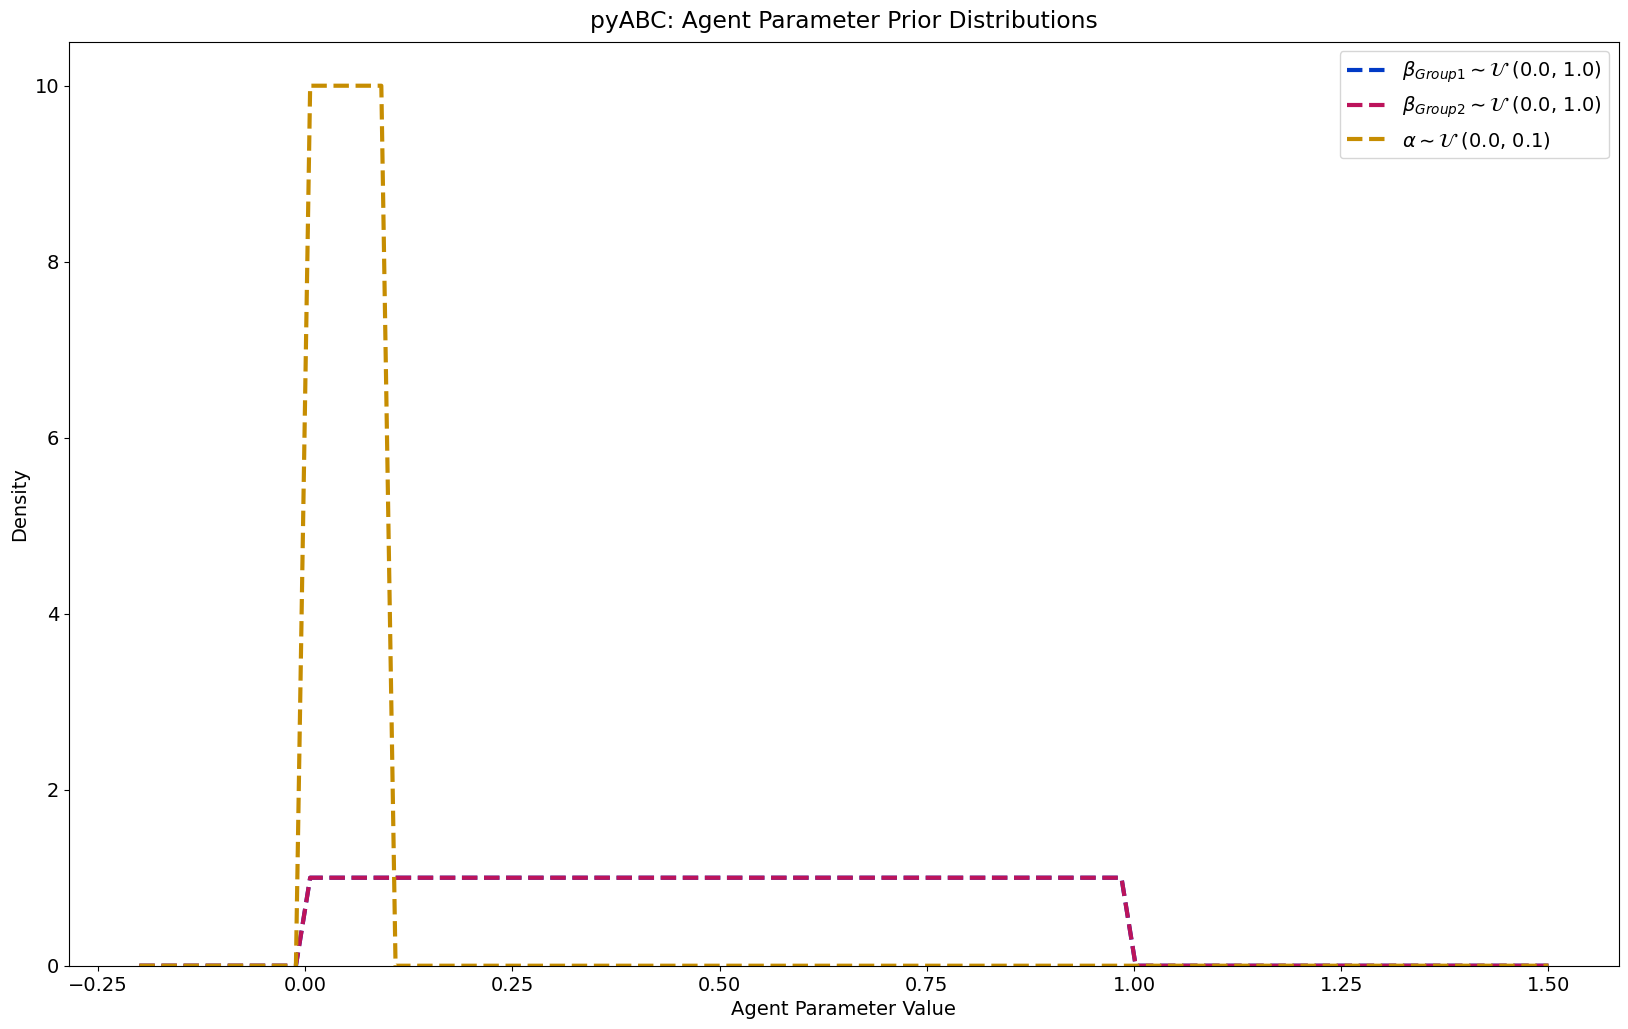

In [11]:
x= np.linspace(-0.2, 1.5, 100)

lines = plt.plot(x, pyabc.Distribution(param=Group1_Beta_param_rv).pdf({"param": x}), '--', label = r'$\beta_{Group 1}$$\sim$$\mathcal{U}$ (0.0, 1.0)', lw = 3, color='#013AC6')
lines = plt.plot(x, pyabc.Distribution(param=Group2_Beta_param_rv).pdf({"param": x}), '--', label = r'$\beta_{Group 2}$$\sim$$\mathcal{U}$ (0.0, 1.0)', lw = 3, color='#BC135B')
lines = plt.plot(x, pyabc.Distribution(param=Alpha_param_rv).pdf({"param": x}), '--', label = r'$\alpha$$\sim$$\mathcal{U}$ (0.0, 0.1)', lw = 3, color='#C68D01') 

plt.title('pyABC: Agent Parameter Prior Distributions', pad=10)
plt.ylabel('Density')
plt.xlabel('Agent Parameter Value')
plt.ylim([0, None])
plt.legend()
#plt.savefig("pyABC_Priors_Het", bbox_inches="tight")

In [14]:
priors = pyabc.Distribution(Beta_One=pyabc.LowerBoundDecorator(Group1_Beta_param_rv, 0.0),
                            Beta_Two=pyabc.LowerBoundDecorator(Group2_Beta_param_rv, 0.0),
                            Alpha=pyabc.LowerBoundDecorator(Alpha_param_rv, 0.0))

### Load Previous Runs from pyABC Database

In [18]:
abc_continued = pyabc.ABCSMC(models=my_model,  
    parameter_priors=priors, 
    distance_function=distance,
    sampler=pyabc.sampler.MulticoreEvalParallelSampler())

ABC.Sampler INFO: Parallelize sampling on 10 processes.


In [19]:
db_path = ("sqlite:///" + "hete_database.db")

In [20]:
abc_continued.load(db_path, 3)

In [21]:
abc_continued.history.n_populations

12

In [22]:
abc_continued.history.get_nr_particles_per_population()

t
-1        1
 0     1000
 1     1000
 2     1000
 3     1000
 4     1000
 5     1000
 6     1000
 7     1000
 8     1000
 9     1000
 10    1000
 11    1000
Name: count, dtype: int64

### Posterior Modes

In [23]:
for i, param in enumerate(priors.keys()):
    for t in range(abc_continued.history.max_t+1):
        df, w = abc_continued.history.get_distribution(m=0, t=t)
        X, Y = pyabc.visualization.kde.kde_1d(df, w, x = param)
        mode = X[np.where(Y == max(Y))]
        print(param, mode)

Beta_One [0.26767779]
Beta_One [0.16416398]
Beta_One [0.14920186]
Beta_One [0.14652457]
Beta_One [0.16532287]
Beta_One [0.15024702]
Beta_One [0.16676716]
Beta_One [0.18288615]
Beta_One [0.20158132]
Beta_One [0.23377126]
Beta_One [0.21832509]
Beta_One [0.24232129]
Beta_Two [0.24527902]
Beta_Two [0.16355329]
Beta_Two [0.16330774]
Beta_Two [0.15906474]
Beta_Two [0.15327569]
Beta_Two [0.14823908]
Beta_Two [0.16708658]
Beta_Two [0.17787507]
Beta_Two [0.21761184]
Beta_Two [0.20786238]
Beta_Two [0.2167801]
Beta_Two [0.23383305]
Alpha [0.04283452]
Alpha [0.08366699]
Alpha [0.04898953]
Alpha [0.05940693]
Alpha [0.0814778]
Alpha [0.05839731]
Alpha [0.07337076]
Alpha [0.03661728]
Alpha [0.02457723]
Alpha [0.01609001]
Alpha [0.02655735]
Alpha [0.01850757]


### Posterior Distributions (Final Population n=12)


In [24]:
pd.set_option('display.max_rows', None)
dist_w = abc_continued.history.get_population_extended(t=11)
dist_w.sort_values('par_Alpha', ascending=True).reset_index()

,particle_id,distance,w,par_Alpha,par_Beta_One,par_Beta_Two,sumstat_mean_inf,sumstat_model_result
0,35375,0.002813,0.001156,0.000245,0.427848,0.275593,684.842,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,35064,0.002833,0.002076,0.000299,0.542844,0.232339,688.014,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,35696,0.003346,0.001014,0.000421,0.369738,0.312915,688.511,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,35014,0.003264,0.001037,0.000531,0.394202,0.294069,690.721,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,35260,0.001949,0.001600,0.000602,0.494378,0.249152,692.26,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
5,35234,0.003203,0.001494,0.000840,0.275999,0.431310,692.93,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6,35228,0.003343,0.000951,0.000856,0.340325,0.341115,687.343,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
7,35313,0.002727,0.001119,0.000859,0.301000,0.379147,690.986,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
8,35518,0.003300,0.001019,0.000860,0.403597,0.288225,689.915,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
9,35676,0.002684,0.000991,0.000887,0.400951,0.291896,688.558,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [25]:
mean_vl = dist_w[['sumstat_mean_inf']].mean()
mean_vl

sumstat_mean_inf    699.732148
dtype: object

In [26]:
_df, _w = abc_continued.history.get_distribution(m=0, t=abc_continued.max_t)
# Merge dataframe and weights and sort by weight (highest weight at the top)
_df['weight'] = _w
posterior_df = _df.sort_values('Alpha', ascending=False).reset_index()
posterior_df

name,id,Alpha,Beta_One,Beta_Two,weight
0,35322,0.099676,0.311086,0.125628,0.003921
1,35832,0.098665,0.176371,0.225002,0.002329
2,35555,0.098425,0.123760,0.310627,0.004964
3,35358,0.096185,0.132785,0.315769,0.004136
4,35139,0.095954,0.382055,0.101878,0.010283
5,35575,0.095800,0.211927,0.204690,0.001596
6,35939,0.094999,0.251894,0.171724,0.001496
7,35743,0.093257,0.149708,0.290232,0.002613
8,35051,0.092913,0.174746,0.248242,0.001653
9,35290,0.092887,0.189011,0.233416,0.001475


In [27]:
observation = {'Beta_One': [0.2],
               'Beta_Two':[0.6],
               'Alpha':[0.01]}

In [28]:
plt.rcParams['font.size'] = '14'

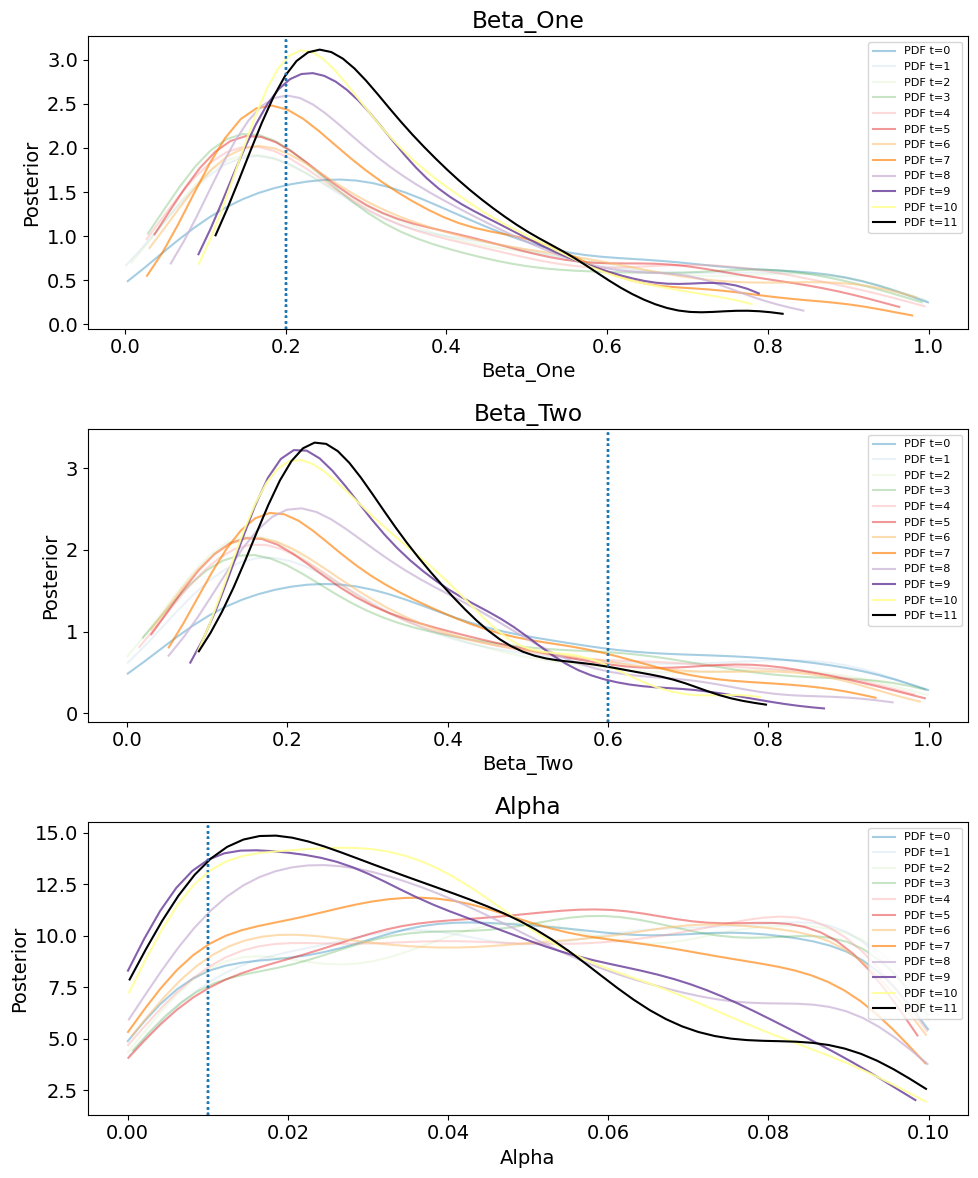

In [29]:
fig, axes = plt.subplots(3,int(len(priors)/2), figsize=(10,12), dpi=100)

for i, param in enumerate(priors.keys()):
    ax = axes.flat[i]
    for t in range(abc_continued.history.max_t + 1):
        df, w = abc_continued.history.get_distribution(m=0, t=t)
        pyabc.visualization.plot_kde_1d(df, w, x=param, ax=ax,
            label=f"PDF t={t}",  refval=observation,                            
            alpha=1.0 if t==0 else float(t)/abc_continued.history.max_t, # Make earlier populations transparent
            color= "black" if t==abc_continued.history.max_t else None # Make the last one black
        ) 
        ax.set_title(f"{param}: {posterior_df.loc[0,param]}")
        ax.set_title(f"{param}")
    ax.legend(fontsize="xx-small")
fig.tight_layout()
#fig.savefig('ch6_pyabc_posterior.png', bbox_inches="tight")

#ax.axvline(x=posterior_df.loc[0,param], color="grey", linestyle="dashed")  

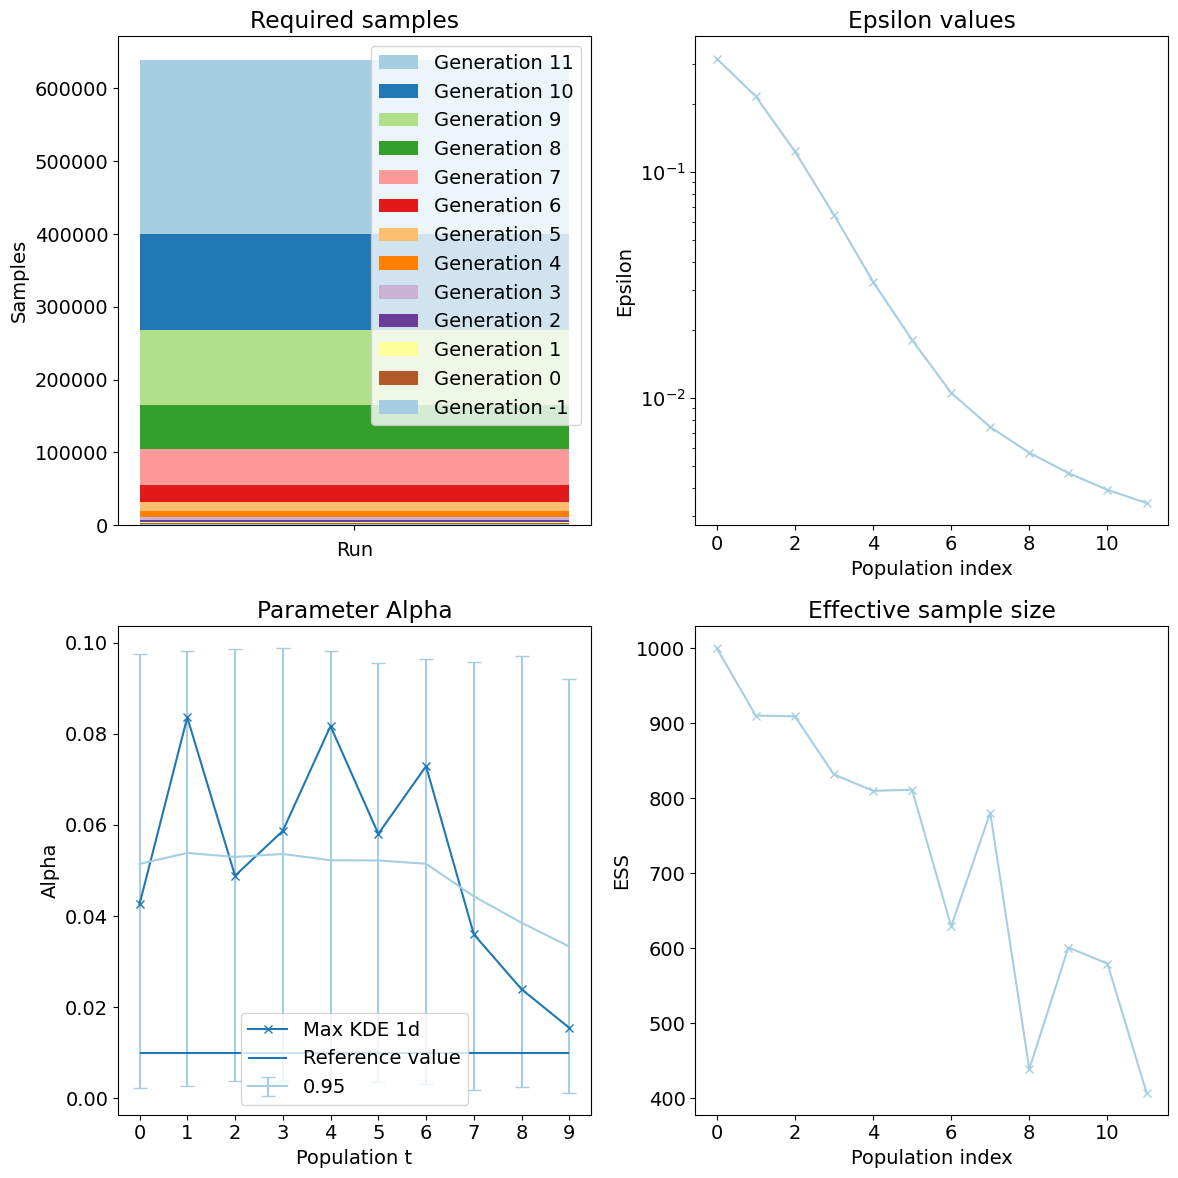

In [31]:
fig, arr_ax = plt.subplots(2, 2, figsize=(12, 12))

pyabc.visualization.plot_sample_numbers(abc_continued.history, ax=arr_ax[0][0])
pyabc.visualization.plot_epsilons(abc_continued.history, ax=arr_ax[0][1])
pyabc.visualization.plot_effective_sample_sizes(abc_continued.history, ax=arr_ax[1][1])
pyabc.visualization.plot_credible_intervals(
    abc_continued.history, levels=[0.95], ts=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
    show_kde_max_1d=True,
    refval=observation, arr_ax=arr_ax[1][0])
fig.tight_layout()

#fig.savefig('ch6_pyabc_output.png', bbox_inches="tight")

### Credibility Intervals

In [32]:
for t in range(abc_continued.history.n_populations):
    df, w = abc_continued.history.get_distribution(m=0, t=t)
    print(f"\nPopulation {t}:")
    for param in df.columns:
        lower = np.percentile(df[param], 2.5)
        upper = np.percentile(df[param], 97.5)
        median = np.percentile(df[param], 50)
        print(f"  {param}: [{lower:.4f}, {upper:.4f}] (median={median:.4f})")


Population 0:
  Alpha: [0.0023, 0.0976] (median=0.0514)
  Beta_One: [0.0388, 0.9427] (median=0.3501)
  Beta_Two: [0.0361, 0.9551] (median=0.3608)

Population 1:
  Alpha: [0.0037, 0.0962] (median=0.0504)
  Beta_One: [0.0496, 0.9185] (median=0.2941)
  Beta_Two: [0.0549, 0.9198] (median=0.3012)

Population 2:
  Alpha: [0.0047, 0.0979] (median=0.0508)
  Beta_One: [0.0541, 0.9133] (median=0.2980)
  Beta_Two: [0.0492, 0.9149] (median=0.2643)

Population 3:
  Alpha: [0.0047, 0.0981] (median=0.0537)
  Beta_One: [0.0672, 0.8974] (median=0.2693)
  Beta_Two: [0.0506, 0.8965] (median=0.2727)

Population 4:
  Alpha: [0.0042, 0.0963] (median=0.0517)
  Beta_One: [0.0636, 0.8658] (median=0.2643)
  Beta_Two: [0.0561, 0.8670] (median=0.2802)

Population 5:
  Alpha: [0.0042, 0.0947] (median=0.0506)
  Beta_One: [0.0701, 0.8291] (median=0.2828)
  Beta_Two: [0.0663, 0.8588] (median=0.2716)

Population 6:
  Alpha: [0.0045, 0.0956] (median=0.0521)
  Beta_One: [0.0797, 0.8377] (median=0.2832)
  Beta_Two: [0.0

array([<Axes: title={'center': 'Parameter Alpha'}, ylabel='Alpha'>,
       <Axes: title={'center': 'Parameter Beta_One'}, ylabel='Beta_One'>,
       <Axes: title={'center': 'Parameter Beta_Two'}, xlabel='Population t', ylabel='Beta_Two'>],
      dtype=object)

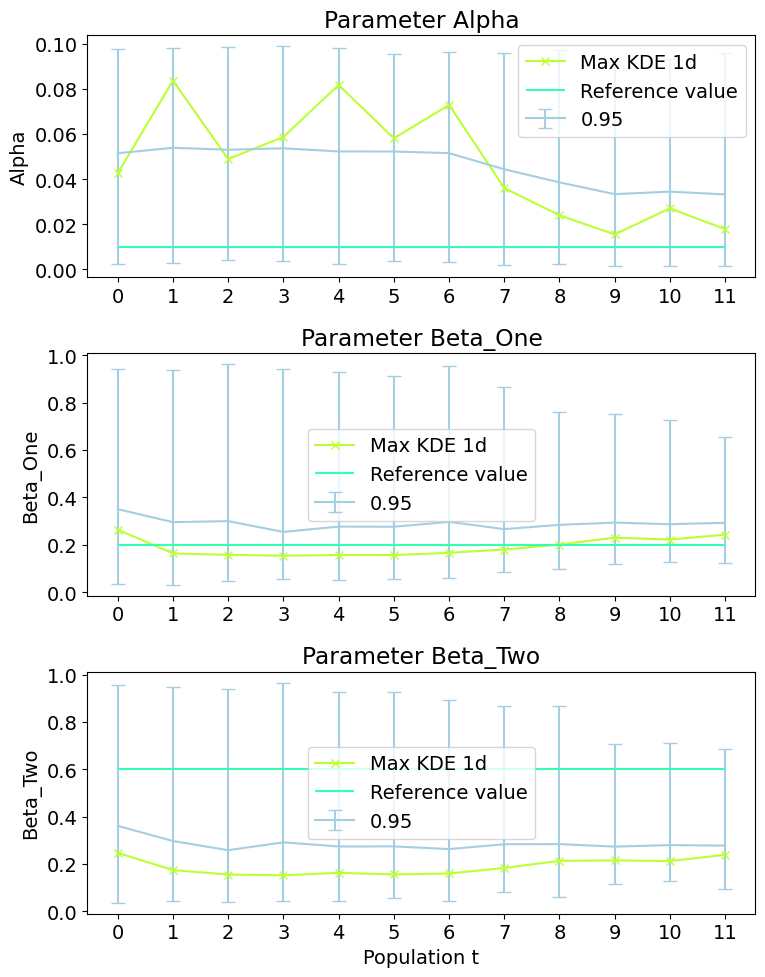

In [33]:
pyabc.visualization.plot_credible_intervals(
    abc_continued.history,
    show_kde_max_1d=True, 
    size=(8,10),
    color_kde_max_1d = '#BBFF33',
    refval_color = '#33FFB0',
    refval=observation)

#plt.savefig('pyabc_output_hete_ci.png', bbox_inches="tight", dpi=128)

### Posterior Distribution Comparison (N = 0 and 11)

Text(0, 0.5, 'Group 2: Beta Parameter')

/opt/miniconda3/envs/jlab/lib/python3.12/site-packages/IPython/core/events.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


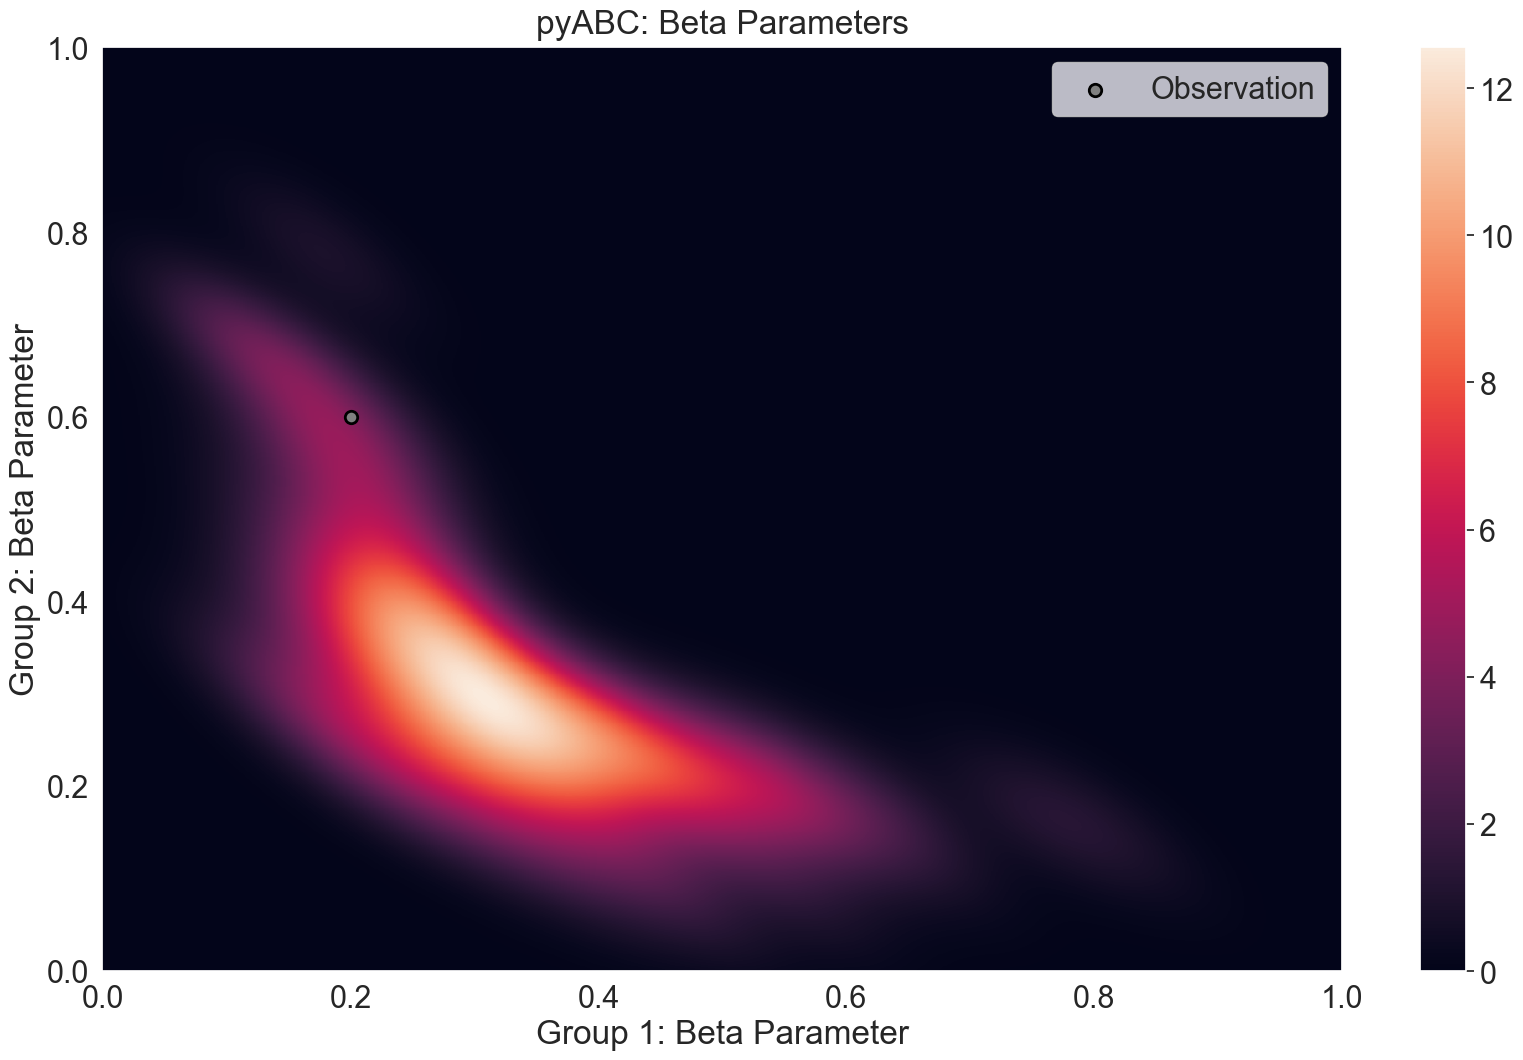

In [34]:
sns.set(font_scale=2) 

# for t in range(abc_continued.history.n_populations):
df, w = abc_continued.history.get_distribution(0, t)
ax = plot_kde_2d(
        df,
        w,
        "Beta_One",
        "Beta_Two",
        xmin=0,
        xmax=1.0,
        ymin=0,
        ymax=1.0,
        numx=1000,
        numy=1000, 
)

ax.scatter([0.2], [0.6], edgecolor="black", facecolor="grey", label="Observation", linewidth=2, s=80)

ax.legend() 

ax.set_title(f"pyABC: Beta Parameters", pad=10)
plt.xlabel("Group 1: Beta Parameter")
plt.ylabel("Group 2: Beta Parameter")
#plt.savefig('Alpha_beta_parameter_values_KDE.png', bbox_inches='tight', dpi=128)

In [30]:
abc_output = abc_continued.history.get_population_extended()

In [48]:
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})


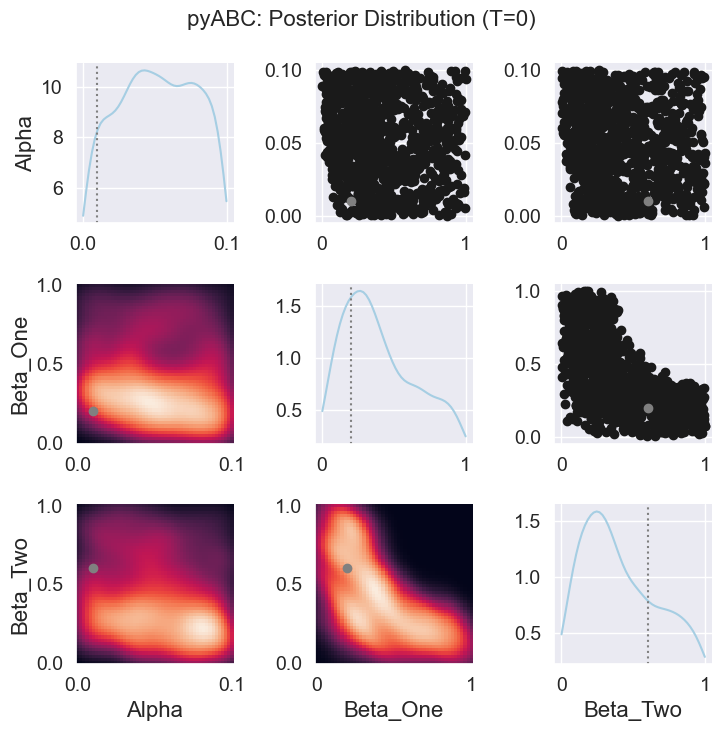

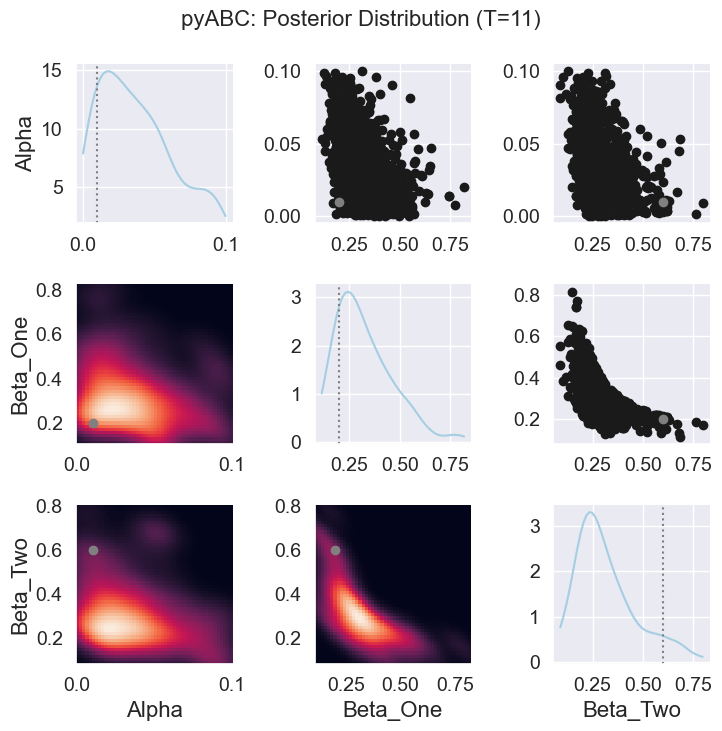

In [49]:
for t in [0, abc_continued.history.max_t]:

    g = pyabc.visualization.plot_kde_matrix_highlevel(
        abc_continued.history,
        t=t,
        refval=gt_par,
        colorbar=False,
        refval_color="grey",
    )

    plt.suptitle(f"pyABC: Posterior Distribution (T={t})", fontsize=16)
    plt.tight_layout()